In [1]:
%load_ext autoreload
%autoreload 2

import argparse
import os
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import binomtest

import utils.behavioral_utils as behavioral_utils
import utils.io_utils as io_utils
import utils.spike_utils as spike_utils
import utils.visualization_utils as visualization_utils

from constants.behavioral_constants import *
from constants.decoding_constants import *
from scripts.anova_analysis.stim_belief_unit_overlap import OUTPUT_PATH, ALPHA
from scripts.pseudo_decoding.belief_partitions.belief_partition_configs import BeliefPartitionConfigs
import scripts.pseudo_decoding.belief_partitions.belief_partitions_io as belief_partitions_io
from scripts.pseudo_decoding.belief_partitions.stim_belief_vector_alignment import (
    prep_behavior_for_feat, group_masks, BASE_GROUPS, MODE, POOL_FILTERS,
    OUTPUT_PATH as ALIGN_OUTPUT_PATH,
)

plt.rcParams.update({"font.size": 16})

# Ordered co-selective example units

`20260820_coselective_example_units.ipynb` plots units selective in *both* runs -- the `N11` set.
Selectivity is a magnitude statement, though: an ANOVA fraction of variance is a function of the
*squared* contrast, so `N11` says a unit's firing separates A from B and separates B from C, and
says nothing about **which way**. This notebook adds the missing half, and searches for the units
where the two steps go the *same* way:

```
A: X not chosen, X not preferred     B: X chosen, X not preferred     C: X chosen, X preferred
        \________ Run S ________/            \________ Run P ________/
         the stimulus contrast                  the belief contrast

    ordered:      fr_A < fr_B < fr_C        or        fr_A > fr_B > fr_C
    not ordered:  fr_A < fr_B > fr_C        or        fr_A > fr_B < fr_C   (B extreme)
```

An ordered unit is the single-unit picture of H2: selection of X moves the rate one way, and
believing X moves it further in the same direction, preference scaling an encoding that is already
there. A unit with B extreme is co-selective but the two codes push against each other.

This is exactly the sign branch that `stim_belief_unit_overlap.py`'s docstring sets aside. Writing
a unit's contribution to the population cosine as

```
    d_s[u] d_p[u]  =  |d_s[u]| |d_p[u]| sign(d_s[u] d_p[u])
```

the ANOVA overlap analysis measures the magnitudes and the population cosine measures a
signed sum; the ordering asked for here is `sign(d_s[u] d_p[u]) = +1`, which neither reports on its
own. So the search below is a two-step filter: **co-selective** (both permutation p-values at or
below alpha, taken straight from the item table) **and ordered** (the two steps share a sign).

### Where the steps come from

Not recomputed here. `stim_belief_align_vectors.pickle` already holds, per (unit, feature, time
bin), the z-scored group means `r_A`, `r_B1`, `r_B2`, `r_C` and the two differences

```
    d_s = v_stim = r_B1 - r_A            d_p = v_pref = r_C - r_B2
```

which is what the population alignment analysis is built from. Two things make it the right source
rather than a fresh pass over firing rates: the A/B/C group definitions are the module's own, and
**the B half-split is the same draw** -- `draw_b_split(session, feat, b, seed=42, shuffle_idx=None)`
is called identically by `run_anova.load_beh` and by the alignment script, so `r_B1` is the B half
Run S saw and `r_B2` is the half Run P saw. The p-values and the steps refer to the same trials.

Using the disjoint halves is not a detail. `r_B` appears in both differences with opposite signs, so
sharing it puts `-Var(r_B)` into their covariance and biases sign agreement *downward* -- Issue 1 of
`stim_belief_alignment_updated.md`, at the single unit rather than the population. Disjoint halves
make the two steps independent under the null, which is what puts the chance level of "ordered" at
exactly 0.5. The pooled-B number is computed below too, and comes out lower, as predicted.

**Caveats, all inherited from the notebook this is modelled on:** these are the most extreme items
out of ~109k, chosen because they are extreme; a single convincing PSTH is not evidence for H2.
Examples are drawn from the 6 regions of interest, a subset of the `whole_pop` the overlap
statistics use. And the PSTHs pool all of B, because halving it would double the noise on the middle
trace for no gain -- this is a picture, not a test.

In [2]:
TRIAL_EVENT = "FeedbackOnsetLong"
N_EXAMPLES = 20

# A -> B is the stimulus step and B -> C the belief step, so B and C take the colours the repo
# already uses for those two variables and A is the neutral starting point
GROUP_TO_COLOR = {
    "A": "grey",
    "B": visualization_utils.MODE_TO_COLOR["feature"],
    "C": visualization_utils.MODE_TO_COLOR["preference"],
}
GROUP_TO_LABEL = {
    "A": "A: not selected, not pref.",
    "B": "B: selected, not pref.",
    "C": "C: selected, pref.",
}

WINDOW_SIZE = 500

# how many of the flagged window's time bins must carry the ordering. The window is 500 ms and the
# bins are 100 ms, so this runs 1 (the ordering appears somewhere in the window) to 5 (it holds
# throughout). Left at 5: the pool is large enough, and an ordering that survives every bin of the
# window the ANOVA flagged is the one a reader can actually see in a PSTH. Counts at every level are
# printed below, so relaxing it is a one-line change with a known cost
MIN_ORDERED_BINS = 5


def read_items(trial_event=TRIAL_EVENT, regions=REGIONS_OF_INTEREST):
    """
    The true run's per-item table: one row per (unit, feature, window), both runs' p-values and
    eta^2, written by stim_belief_unit_overlap.py.

    Same reader as 20260820_coselective_example_units.ipynb, including the restriction to the 6
    regions the decoding analyses use -- NARROWER than the `whole_pop` the overlap statistics are
    computed over. Pass regions=None for that wider set.
    """
    items = pd.read_pickle(os.path.join(OUTPUT_PATH, f"{trial_event}_item_pvals.pickle"))
    items = items[items.in_good_units].copy()
    if regions is None:
        return items
    in_roi = items.structure_level2_cleaned.isin(regions)
    print(f"{in_roi.sum()} of {len(items)} items are in the {len(regions)} regions of interest "
          f"({items[in_roi].PseudoUnitID.nunique()} of {items.PseudoUnitID.nunique()} units)")
    return items[in_roi].copy()


def read_vectors(trial_event=TRIAL_EVENT):
    """
    The per-unit group means the population alignment analysis was built from, one row per
    (unit, feature, time bin).

    The path is resolved through belief_partitions_io.get_dir_name off the alignment script's own
    constants rather than spelled out, so it tracks that script if its naming changes. Subject
    `both` and shuffle None: the true run over both animals, which is the only case with a matching
    item table.

    Two columns are added. WindowStartMilli renames TimeIdx into the milliseconds the ANOVA windows
    are indexed by, so the two tables join. r_B recombines the halves as a trial-count weighted
    mean -- it is what the PSTHs show, and it is used ONLY as a display check, never for the search
    (see the header: sharing r_B between the two steps biases sign agreement downward).
    """
    args = argparse.Namespace(**BeliefPartitionConfigs()._asdict())
    args.subject, args.trial_event = "both", trial_event
    args.beh_filters, args.base_output_path, args.shuffle_idx = POOL_FILTERS, ALIGN_OUTPUT_PATH, None
    path = os.path.join(belief_partitions_io.get_dir_name(args, make_dir=False), f"{MODE}_vectors.pickle")

    vectors = pd.read_pickle(path)
    ti = get_trial_interval(trial_event)
    vectors["WindowStartMilli"] = vectors.TimeIdx * ti.interval_size - ti.pre_interval
    vectors["r_B"] = ((vectors.n_B1 * vectors.r_B1 + vectors.n_B2 * vectors.r_B2)
                      / (vectors.n_B1 + vectors.n_B2))
    vectors["d_stim_pool"] = vectors.r_B - vectors.r_A
    vectors["d_pref_pool"] = vectors.r_C - vectors.r_B
    print(f"{len(vectors)} (unit, feat, bin) rows from {path}")
    return vectors


def region_abbrev(region):
    """
    Short region label. REGION_TO_ABBREV only covers the 6 regions of interest, and these examples
    can land anywhere, so anything else falls back to the code the region string already ends in.
    """
    return visualization_utils.REGION_TO_ABBREV.get(region, str(region).split("_")[-1])

## Attaching the two steps to each item

An item is a triple (unit, feature, window) and a window is 500 ms; the saved vectors are per 100 ms
bin. So each item expands to its 5 bins, picks up `v_stim` and `v_pref` there, and collapses back to

- `d_stim`, `d_pref` -- the two steps averaged over the window, whose signs define `ordered`
- `n_ordered` -- how many of the 5 bins individually carry the ordering, which `MIN_ORDERED_BINS`
  thresholds
- `min_step` -- `min(|d_stim|, |d_pref|)`, the weaker of the two steps. An ordering is only as
  visible as its smaller step, so this is what ranks examples once the p-values tie. It is in units
  of the pooled within-(unit, bin) sd, which -- unlike eta^2 -- **is** comparable across units

and the pooled-B versions of each, suffixed `_pool`.

In [3]:
def add_ordering(items, vectors, trial_event=TRIAL_EVENT, window_size=WINDOW_SIZE):
    """
    Adds the two group-mean steps, and the ordering they imply, to every row of the item table.

    Each item is repeated once per 100 ms bin inside its 500 ms window, joined to the saved vectors
    on (unit, feat, bin), and collapsed back. Both merges are validated: `m:1` because the vectors
    hold one row per (unit, feat, bin), `1:1` because the collapse must return the item table's own
    rows. A missing bin is an error rather than a nan -- an item whose steps are unknown would
    silently count as "not ordered" and deflate every fraction below.
    """
    ti = get_trial_interval(trial_event)
    n_bins = window_size // ti.interval_size
    key = ["PseudoUnitID", "feat", "WindowStartMilli"]

    binned = items.loc[items.index.repeat(n_bins), key].copy()
    binned["bin_start"] = (binned.WindowStartMilli
                           + np.tile(np.arange(n_bins) * ti.interval_size, len(items)))
    step_cols = ["v_stim", "v_pref", "d_stim_pool", "d_pref_pool"]
    binned = binned.merge(
        vectors[["PseudoUnitID", "feat", "WindowStartMilli"] + step_cols]
            .rename(columns={"WindowStartMilli": "bin_start"}),
        on=["PseudoUnitID", "feat", "bin_start"], how="left", validate="m:1",
    )
    missing = binned[step_cols].isna().any(axis=1)
    if missing.any():
        raise ValueError(f"{missing.sum()} of {len(binned)} (item, bin) rows have no saved vector -- "
                         f"the item table and {MODE}_vectors.pickle disagree on the unit or bin set")

    # sign(d_s) * sign(d_p) > 0 IS "A < B < C or A > B > C": the two steps point the same way
    binned["ord_bin"] = np.sign(binned.v_stim) * np.sign(binned.v_pref) > 0
    binned["ord_bin_pool"] = np.sign(binned.d_stim_pool) * np.sign(binned.d_pref_pool) > 0

    agg = binned.groupby(key, sort=False).agg(
        d_stim=("v_stim", "mean"), d_pref=("v_pref", "mean"),
        d_stim_pool=("d_stim_pool", "mean"), d_pref_pool=("d_pref_pool", "mean"),
        n_ordered=("ord_bin", "sum"), n_ordered_pool=("ord_bin_pool", "sum"),
    ).reset_index()

    out = items.merge(agg, on=key, how="left", validate="1:1")
    out["ordered"] = np.sign(out.d_stim) * np.sign(out.d_pref) > 0
    out["ordered_pool"] = np.sign(out.d_stim_pool) * np.sign(out.d_pref_pool) > 0
    # the full shape, not just the ordered ones' sign: the two unordered shapes have to be
    # distinguishable too, since the complement section below displays and plots them
    up, down = out.d_stim > 0, out.d_stim < 0
    out["direction"] = np.select(
        [up & (out.d_pref > 0), down & (out.d_pref < 0), up & (out.d_pref < 0), down & (out.d_pref > 0)],
        ["A<B<C", "A>B>C", "A<B>C", "A>B<C"], default="flat",
    )
    out["min_step"] = np.minimum(out.d_stim.abs(), out.d_pref.abs())
    out["p_worse"] = out[["p_s", "p_p"]].max(axis=1)
    out["n_bins"] = n_bins
    return out


items = add_ordering(read_items(), read_vectors())
coselective = items[(items.p_s <= ALPHA) & (items.p_p <= ALPHA)].copy()

print(f"\n{len(items)} items, {len(coselective)} co-selective at alpha={ALPHA} "
      f"({100 * len(coselective) / len(items):.2f}%), "
      f"across {coselective.PseudoUnitID.nunique()} distinct units")

109445 of 170726 items are in the 6 regions of interest (869 of 1378 units)
209121 (unit, feat, bin) rows from /data/patrick_res/stim_belief_alignment/both_FeedbackOnsetLong_Response_Correct/stim_belief_align_vectors.pickle

109445 items, 555 co-selective at alpha=0.05 (0.51%), across 186 distinct units


## How often is a co-selective unit ordered?

Worth printing before picking examples, because it sets what the examples are examples *of*.

The chance level is exactly 0.5, and that is a property of the design rather than an assumption:
`d_s` and `d_p` are built from disjoint trials (`r_B1` vs `r_B2`, and A and C never overlap), so
under the null they are independent and their signs agree half the time. Selection on the two
p-values does not disturb that -- an ANOVA fraction of variance is a function of the squared
contrast, so it is blind to sign.

Two things to read off the cell below:

- The fraction among **all** items comes out at 0.488 -- within about a point of chance, and the
  residual leans the same way the co-selective excess does, which is what diluting some real
  B-extreme structure across 109k mostly-unselective items looks like. Nothing like the offset the
  pooled-B line carries.
- The **pooled-B** fraction sits *below* the half-split one. That is the single-unit form of Issue 1:
  sharing `r_B` between the two differences puts `-Var(r_B)` in their covariance and manufactures
  anti-ordering. It is the reason the search runs on the halves.

The binomial p-values are printed for scale only. Items are **not** independent -- adjacent windows
overlap by 80%, and the 12 features share trials within a session -- so they are anticonservative.
The per-unit collapse (each unit's single best co-selective item) removes the window dependence and
is the more honest of the two; neither is a substitute for the shuffle-based statistics in
`20260820_visualize_stim_belief_unit_overlap.ipynb`.

In [4]:
def ordering_summary(items, coselective):
    """Ordered fractions, against the 0.5 the disjoint B halves put the null at."""
    def line(label, mask_df, col):
        n, k = len(mask_df), int(mask_df[col].sum())
        p = binomtest(k, n, 0.5).pvalue if n else np.nan
        print(f"  {label:<38} {k:>5} / {n:<6} = {k / n:.3f}   binom p = {p:.2e}")

    print(f"ordered fraction (chance = 0.500):")
    line("all items, half-split B", items, "ordered")
    line("co-selective, half-split B", coselective, "ordered")
    line("co-selective, pooled B (biased)", coselective, "ordered_pool")
    # one item per unit -- its strongest -- so overlapping windows can't count the same unit twice
    best = coselective.sort_values(["p_worse", "min_step"], ascending=[True, False]) \
                      .drop_duplicates(subset="PseudoUnitID")
    line("co-selective, one item per unit", best, "ordered")

    print(f"\npool available at each MIN_ORDERED_BINS (co-selective only):")
    for min_bins in range(1, coselective.n_bins.iloc[0] + 1):
        halves = coselective[coselective.n_ordered >= min_bins]
        shown = halves[halves.n_ordered_pool >= min_bins]
        print(f"  >= {min_bins} of {coselective.n_bins.iloc[0]} bins ordered: "
              f"{len(halves):>4} items / {halves.PseudoUnitID.nunique():>3} units"
              f"   (also ordered on pooled B: {len(shown):>4} items / "
              f"{shown.PseudoUnitID.nunique():>3} units)")


ordering_summary(items, coselective)

ordered fraction (chance = 0.500):
  all items, half-split B                53438 / 109445 = 0.488   binom p = 8.31e-15
  co-selective, half-split B               181 / 555    = 0.326   binom p = 1.82e-16
  co-selective, pooled B (biased)          143 / 555    = 0.258   binom p = 3.41e-31
  co-selective, one item per unit           65 / 186    = 0.349   binom p = 4.88e-05

pool available at each MIN_ORDERED_BINS (co-selective only):
  >= 1 of 5 bins ordered:  305 items / 129 units   (also ordered on pooled B:  240 items / 106 units)
  >= 2 of 5 bins ordered:  221 items / 101 units   (also ordered on pooled B:  159 items /  68 units)
  >= 3 of 5 bins ordered:  186 items /  79 units   (also ordered on pooled B:  129 items /  52 units)
  >= 4 of 5 bins ordered:  147 items /  63 units   (also ordered on pooled B:   92 items /  40 units)
  >= 5 of 5 bins ordered:  106 items /  48 units   (also ordered on pooled B:   49 items /  26 units)


## The ordered units

`find_ordered` is the search proper: co-selective **and** ordered in at least `MIN_ORDERED_BINS` of
the flagged window's bins, strongest first.

Ranking follows the notebook this is modelled on -- `p_worse = max(p_s, p_p)` ascending, since an
item is only as co-selective as its weaker side -- and breaks the ties at the p-value floor on
`min_step` descending rather than on eta^2. Both are display heuristics for picking visually clear
examples, not statistics, but `min_step` is the better of the two here: it is the quantity the
ordering is about, and being in sd units it compares across units in a way eta^2 does not.

`require_pooled` is what separates the claim from the picture. The search itself runs on the
half-split steps, which are the unbiased ones; examples additionally have to be ordered on the
pooled B, because pooled B is what the PSTH draws and an example that only orders on the halves
would be a figure contradicting its own caption.

In [5]:
def find_ordered(items, min_bins=MIN_ORDERED_BINS, alpha=ALPHA, require_pooled=True, direction=None):
    """
    Co-selective items whose two steps point the same way, strongest first.

    `min_bins` is how many of the window's bins must individually carry the ordering.
    `require_pooled` additionally demands it of the pooled-B steps -- a display filter, so that what
    the PSTH shows agrees with why the unit was picked (see the markdown above).
    `direction` restricts to "A<B<C" or "A>B>C"; None keeps both.
    """
    hits = items[(items.p_s <= alpha) & (items.p_p <= alpha) & (items.n_ordered >= min_bins)]
    if require_pooled:
        hits = hits[hits.n_ordered_pool >= min_bins]
    if direction is not None:
        hits = hits[hits.direction == direction]
    return hits.sort_values(["p_worse", "min_step"], ascending=[True, False]).copy()


def pick_examples(candidates, n=N_EXAMPLES):
    """
    One row per unit -- its best (feature, window) -- so n examples are n different neurons.

    Without this the top of the list is often one unit at several adjacent windows, which overlap by
    80% and are therefore the same observation shown repeatedly.
    """
    return candidates.drop_duplicates(subset="PseudoUnitID").head(n)


ordered = find_ordered(items)
examples = pick_examples(ordered)

print(f"{len(ordered)} co-selective items ordered in all {MIN_ORDERED_BINS} bins of their window "
      f"(both step definitions), across {ordered.PseudoUnitID.nunique()} distinct units")
print(f"direction: {ordered.direction.value_counts().to_dict()}")
print(f"showing {len(examples)} of them\n")

print("units contributing, by region:")
print(ordered.groupby("structure_level2_cleaned").PseudoUnitID.nunique()
      .rename(region_abbrev).sort_values(ascending=False).to_string(), "\n")

cols = ["PseudoUnitID", "feat", "WindowStartMilli", "subject", "structure_level2_cleaned",
        "p_s", "p_p", "d_stim", "d_pref", "min_step", "direction"]
display(examples[cols].reset_index(drop=True))

49 co-selective items ordered in all 5 bins of their window (both step definitions), across 26 distinct units
direction: {'A>B>C': 28, 'A<B<C': 21}
showing 20 of them

units contributing, by region:
structure_level2_cleaned
LPFC    11
ITC      8
AMY      5
HC       2 



,PseudoUnitID,feat,WindowStartMilli,subject,structure_level2_cleaned,p_s,p_p,d_stim,d_pref,min_step,direction
0,2018092500,GREEN,-600,SA,inferior_temporal_cortex_ITC,0.01,0.01,0.932679,0.844623,0.844623,A<B<C
1,2018090600,CYAN,-300,SA,inferior_temporal_cortex_ITC,0.01,0.01,-0.608981,-0.532588,0.532588,A>B>C
2,2019053107,CYAN,800,BL,inferior_temporal_cortex_ITC,0.01,0.01,0.336045,0.596258,0.336045,A<B<C
3,2018090719,ESCHER,400,SA,amygdala_Amy,0.02,0.02,0.397290,0.510625,0.397290,A<B<C
4,2019081500,CYAN,-300,BL,amygdala_Amy,0.02,0.01,-0.521671,-0.347405,0.347405,A>B>C
5,2018100508,CIRCLE,-500,SA,inferior_temporal_cortex_ITC,0.01,0.02,-0.322408,-0.354151,0.322408,A>B>C
6,2018080611,CIRCLE,0,SA,lateral_prefrontal_cortex_lat_PFC,0.01,0.03,0.437056,0.559984,0.437056,A<B<C
7,2018100801,POLKADOT,-400,SA,inferior_temporal_cortex_ITC,0.03,0.02,-0.415674,-0.386364,0.386364,A>B>C
8,2018080612,TRIANGLE,-1800,SA,lateral_prefrontal_cortex_lat_PFC,0.01,0.03,0.351378,0.484988,0.351378,A<B<C
9,2018090618,SQUARE,-1200,SA,medial_pallium_MPal,0.03,0.02,-0.309546,-0.377370,0.309546,A>B>C


### PSTHs

Raw firing rate against time to feedback, averaged over each group's trials with a standard error
band, in the same axes as `20260820_coselective_example_units.ipynb`. The shaded span is the 500 ms
window the unit was flagged in. One figure per unit, each with its own x axis, so a single panel can
be copied out on its own.

Read **A vs B for the stimulus step** and **B vs C for the belief step**. In these panels the two go
the same way, so the three levels come out stacked: preference moving the rate further in whatever
direction selection already moved it.

The direction and the two steps each unit was selected on are in the table printed above, not on the
figure -- `d_stim` / `d_pref` there are z-scored half-split steps, on a different scale from the raw
Hz the traces show.


In [6]:
def load_unit_psth(unit_id, feat, trial_event=TRIAL_EVENT):
    """
    One unit's trial-by-trial firing rates, labelled with its A/B/C group.

    The session is recoverable from the PseudoUnitID, which is int(session) * 100 + UnitID, so a
    row of the item table is enough to find the data. Groups come from stim_belief_vector_alignment
    rather than being redefined here -- that module is what the population analysis and the ANOVA
    runs both use, so the three cells are identical by construction rather than by hand.
    """
    session = str(unit_id // 100)
    subject = behavioral_utils.get_sub_for_session(session)

    args = argparse.Namespace(
        subject=subject, trial_event=trial_event, fr_type="firing_rates",
        trial_interval=get_trial_interval(trial_event), time_range=None,
    )
    beh = prep_behavior_for_feat(
        behavioral_utils.get_valid_belief_beh_for_sub_sess(subject, session), feat
    )
    masks = group_masks(beh)
    beh["group"] = np.select([masks[g] for g in BASE_GROUPS], BASE_GROUPS, default=None)
    beh = beh[beh.group.notna()]

    frs = io_utils.get_frs_from_args(args, session)
    frs = frs[frs.PseudoUnitID == unit_id]
    return pd.merge(frs, beh[["TrialNumber", "group"]], on="TrialNumber"), subject

# shared by every panel now that each is its own figure
FB_TICKS = [-1.5, -1, -.5, 0, .5, 1, 1.5]


def plot_psth(row, ax):
    """One example unit, on a supplied axes."""
    psth, subject = load_unit_psth(row.PseudoUnitID, row.feat)
    n_per_group = psth.groupby("group").TrialNumber.nunique()

    sns.lineplot(
        psth, x="Time", y="FiringRate", hue="group", hue_order=BASE_GROUPS,
        palette=GROUP_TO_COLOR, linewidth=3, errorbar="se", ax=ax
    )
    # the window the unit was flagged in, so the traces can be read where the test looked
    w_start, w_end = row.WindowStartMilli / 1000, (row.WindowStartMilli + WINDOW_SIZE) / 1000
    ax.axvspan(w_start, w_end, color="grey", alpha=0.12, linewidth=0)
    ax.axvline(-.8, color="grey", linestyle="dotted", linewidth=3)
    ax.axvline(0, color="grey", linestyle="dotted", linewidth=3)

    ax.set_ylabel("firing rate (Hz)")
    # every panel carries its own x axis: the figures are drawn one per unit so that a single PSTH
    # can be copied out on its own, and a copied panel with no x axis is unreadable
    ax.set_xlabel("Time to feedback (s)")
    ax.set_xticks(FB_TICKS)
    ax.set_xticklabels(FB_TICKS)
    # identity only -- which unit, which animal and region, which feature X the groups are relative
    # to, and the trial counts behind each trace. The numbers that selected the unit are in the
    # table printed above each set, not on the figure
    ax.set_title(
        f"unit {int(row.PseudoUnitID)}  ({subject}, {region_abbrev(row.structure_level2_cleaned)})"
        f"  |  X = {row.feat}\n"
        f"n = {', '.join(f'{g}:{n_per_group.get(g, 0)}' for g in BASE_GROUPS)}",
        fontsize=11,
    )
    ax.get_legend().remove()
    return ax


def plot_examples(examples):
    """
    One standalone figure per example unit rather than a single stacked column, so an individual
    PSTH can be copied out without cropping the ones above and below it. Returns the figures and
    their axes, in the order the examples came in.
    """
    figs, axs = [], []
    for _, row in examples.iterrows():
        fig, ax = plt.subplots(figsize=(8.5, 3.0))
        plot_psth(row, ax)
        # legend beside each panel, the repo's usual placement. With one panel per figure there is
        # no stack to share a legend across, and this keeps every figure self-contained
        handles = [plt.Line2D([], [], color=GROUP_TO_COLOR[g], linewidth=6, label=GROUP_TO_LABEL[g])
                   for g in BASE_GROUPS]
        ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False,
                  fontsize=11)
        visualization_utils.format_plot([ax])
        fig.tight_layout()
        figs.append(fig)
        axs.append(ax)
    return figs, axs


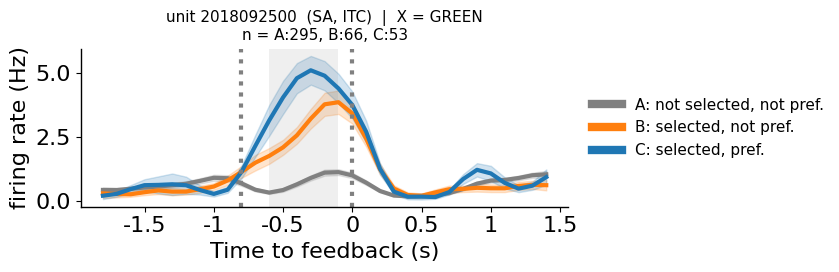

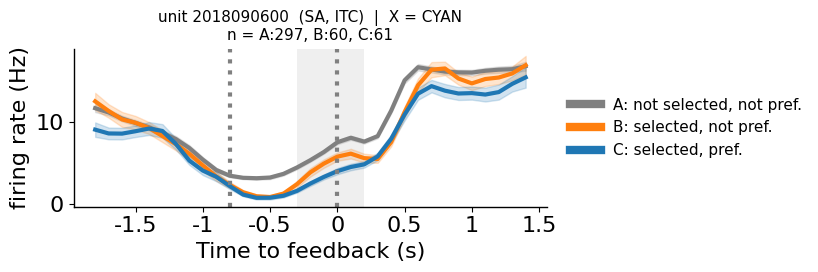

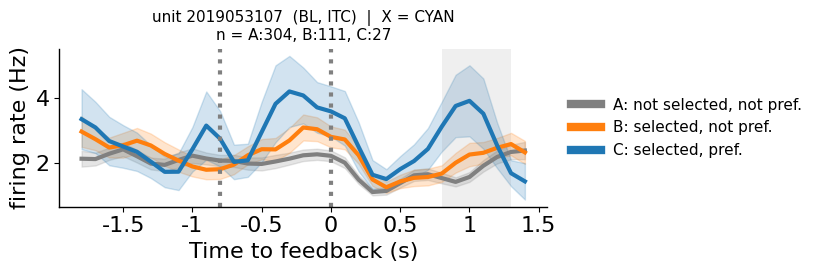

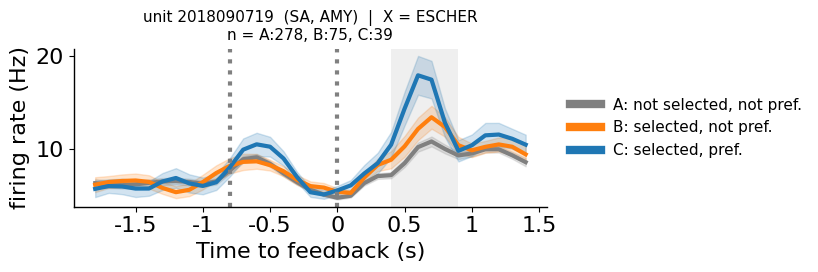

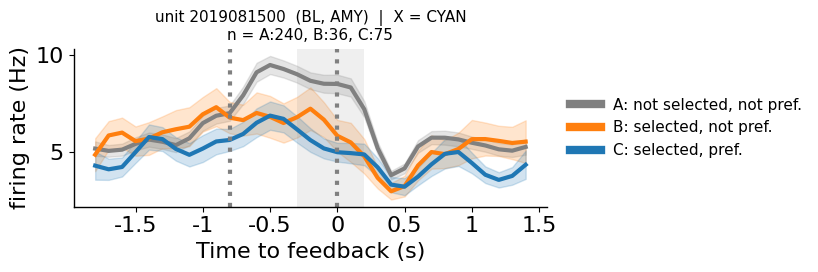

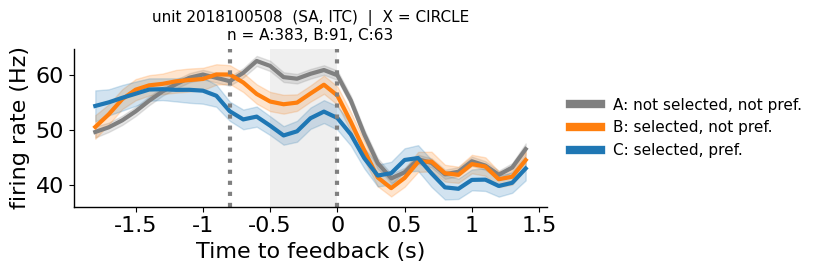

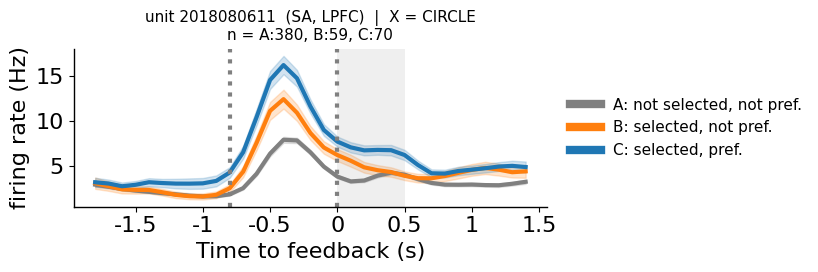

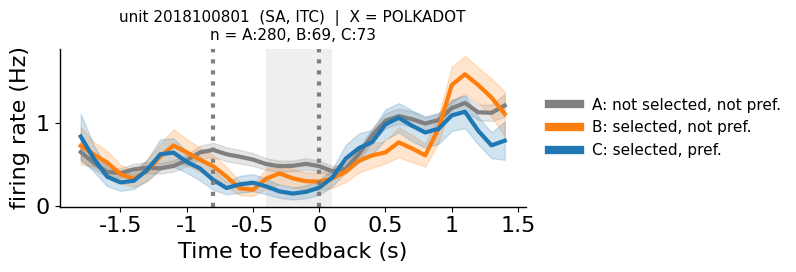

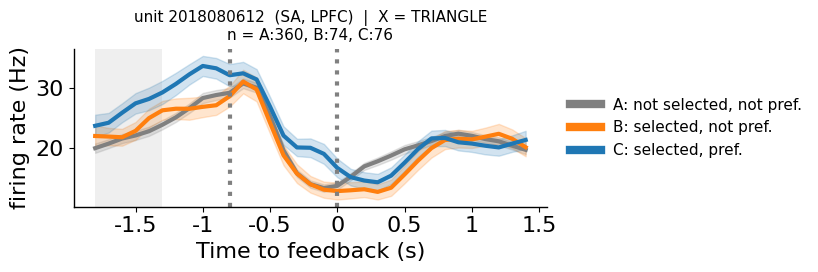

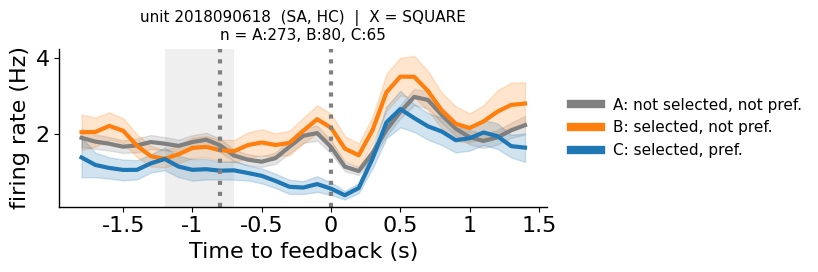

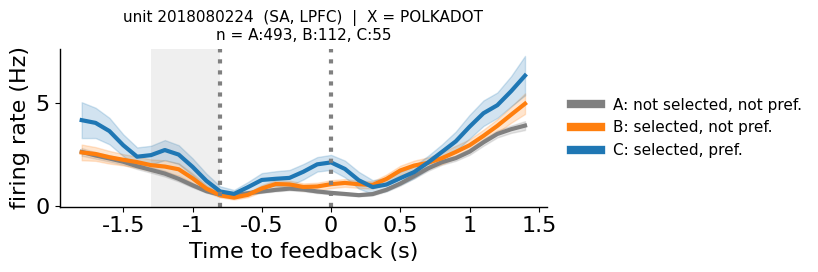

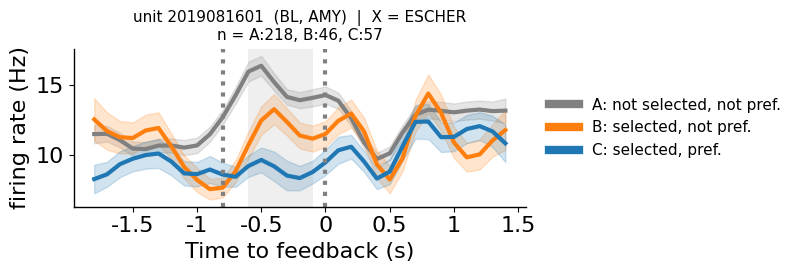

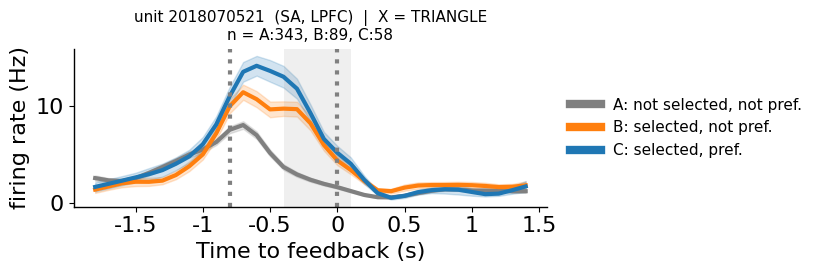

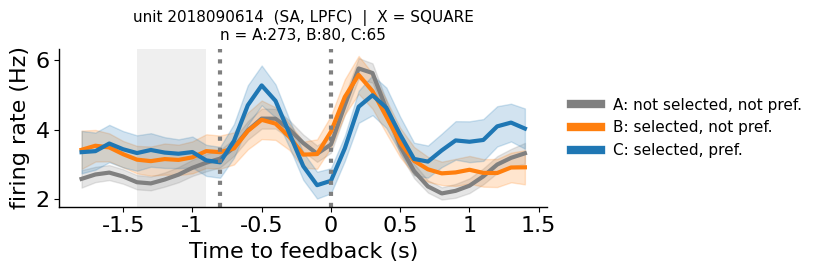

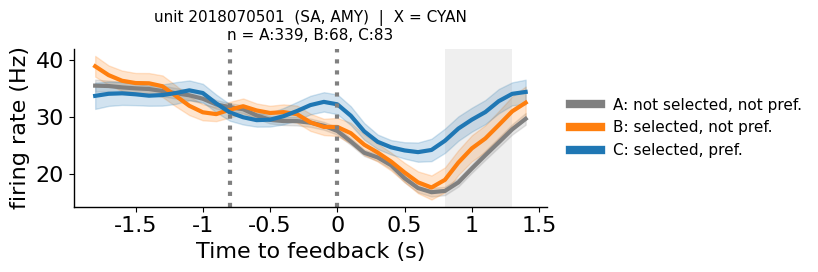

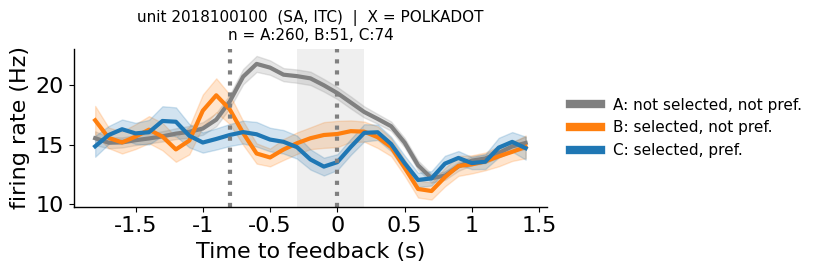

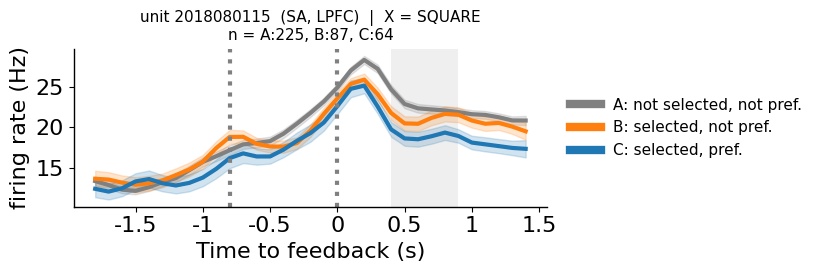

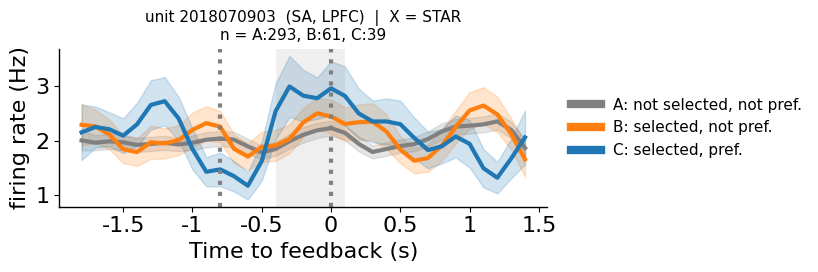

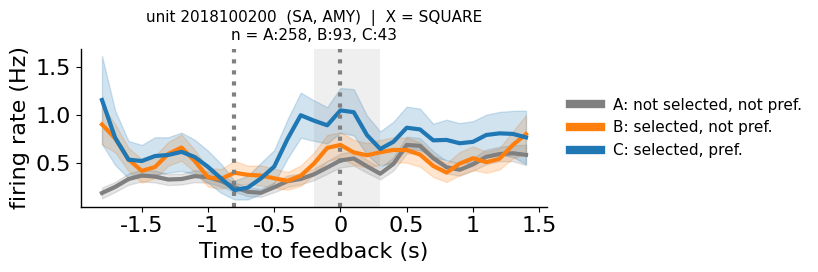

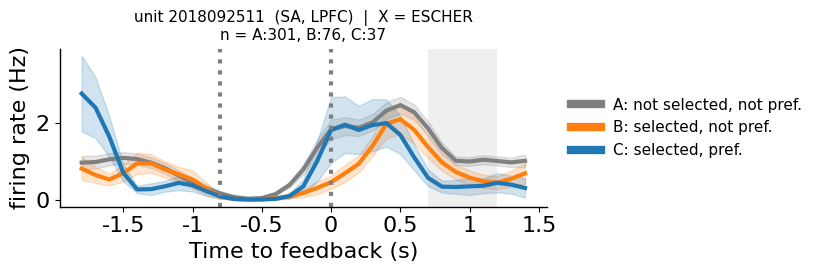

In [7]:
figs, axs = plot_examples(examples)

---

## One direction at a time

The same set split by sign. `A<B<C` is the H2 picture as the note draws it -- selection raises the
rate and preference raises it further. `A>B>C` is the identical geometry with the unit's tuning
inverted: both steps are still positive along the unit's own preferred direction, and it contributes
to the population cosine exactly as the increasing units do.

Nothing new is computed here; these are the same items as above, re-picked within each direction so
that a direction with fewer strong units still gets shown.

In [8]:
n_per_direction = 6

for direction in ["A<B<C", "A>B>C"]:
    hits = find_ordered(items, direction=direction)
    print(f"{direction}: {len(hits)} items across {hits.PseudoUnitID.nunique()} units")
    display(pick_examples(hits, n_per_direction)[cols].reset_index(drop=True))

A<B<C: 21 items across 11 units


,PseudoUnitID,feat,WindowStartMilli,subject,structure_level2_cleaned,p_s,p_p,d_stim,d_pref,min_step,direction
0,2018092500,GREEN,-600,SA,inferior_temporal_cortex_ITC,0.01,0.01,0.932679,0.844623,0.844623,A<B<C
1,2019053107,CYAN,800,BL,inferior_temporal_cortex_ITC,0.01,0.01,0.336045,0.596258,0.336045,A<B<C
2,2018090719,ESCHER,400,SA,amygdala_Amy,0.02,0.02,0.397290,0.510625,0.397290,A<B<C
3,2018080611,CIRCLE,0,SA,lateral_prefrontal_cortex_lat_PFC,0.01,0.03,0.437056,0.559984,0.437056,A<B<C
4,2018080612,TRIANGLE,-1800,SA,lateral_prefrontal_cortex_lat_PFC,0.01,0.03,0.351378,0.484988,0.351378,A<B<C
5,2018080224,POLKADOT,-1300,SA,lateral_prefrontal_cortex_lat_PFC,0.02,0.03,0.291556,0.398593,0.291556,A<B<C


A>B>C: 28 items across 16 units


,PseudoUnitID,feat,WindowStartMilli,subject,structure_level2_cleaned,p_s,p_p,d_stim,d_pref,min_step,direction
0,2018090600,CYAN,-300,SA,inferior_temporal_cortex_ITC,0.01,0.01,-0.608981,-0.532588,0.532588,A>B>C
1,2019081500,CYAN,-300,BL,amygdala_Amy,0.02,0.01,-0.521671,-0.347405,0.347405,A>B>C
2,2018100508,CIRCLE,-500,SA,inferior_temporal_cortex_ITC,0.01,0.02,-0.322408,-0.354151,0.322408,A>B>C
3,2018100801,POLKADOT,-400,SA,inferior_temporal_cortex_ITC,0.03,0.02,-0.415674,-0.386364,0.386364,A>B>C
4,2018090618,SQUARE,-1200,SA,medial_pallium_MPal,0.03,0.02,-0.309546,-0.377370,0.309546,A>B>C
5,2019081601,ESCHER,-600,BL,amygdala_Amy,0.04,0.04,-0.440021,-0.450518,0.440021,A>B>C


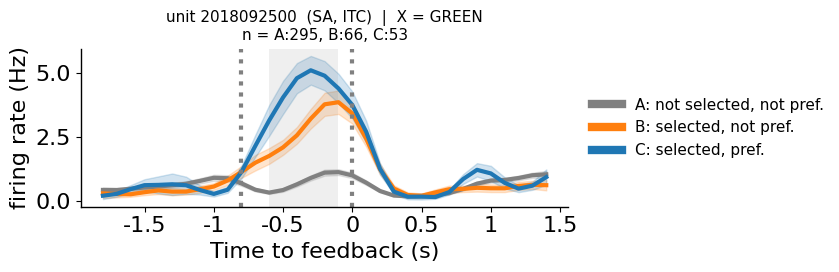

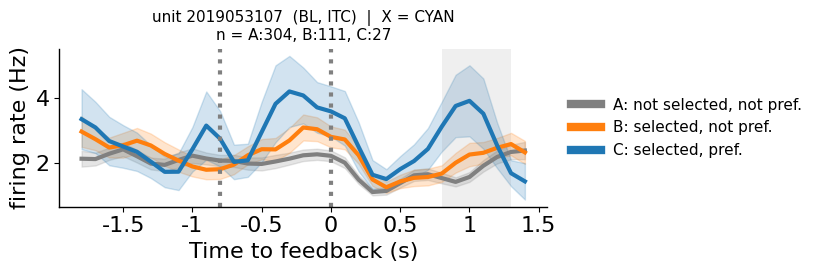

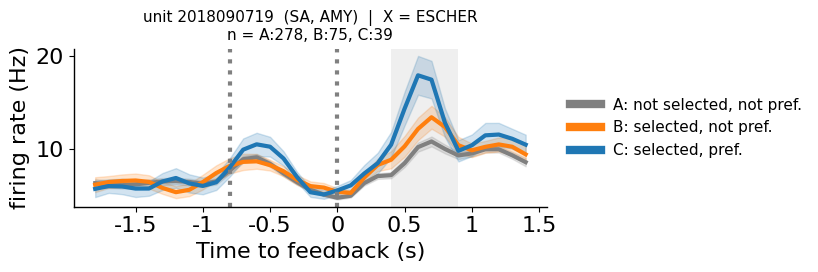

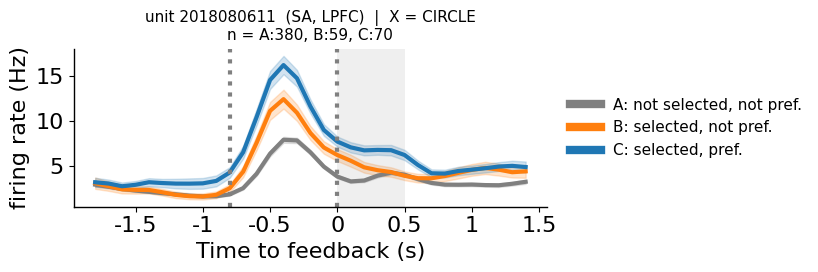

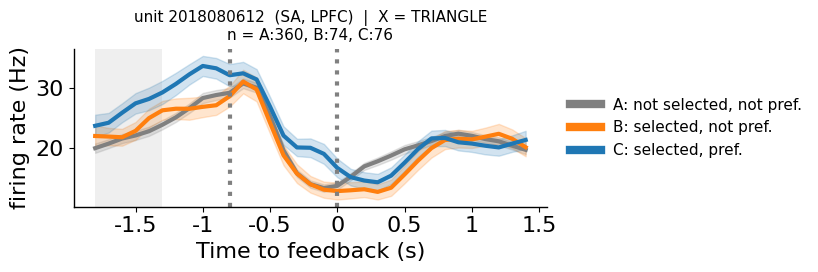

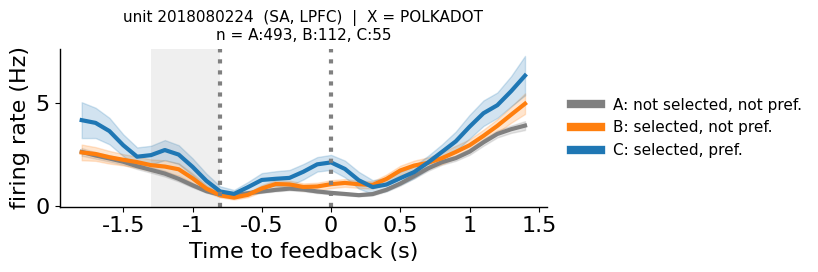

In [9]:
figs, axs = plot_examples(pick_examples(find_ordered(items, direction="A<B<C"), n_per_direction))


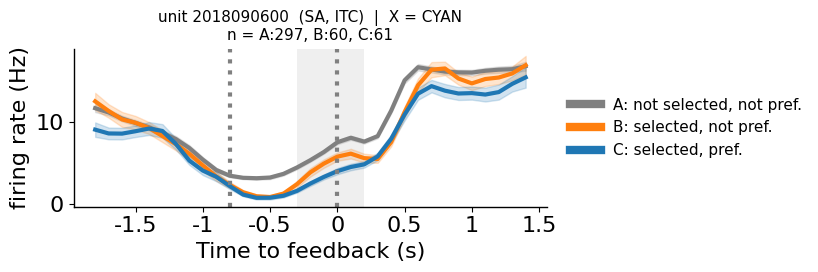

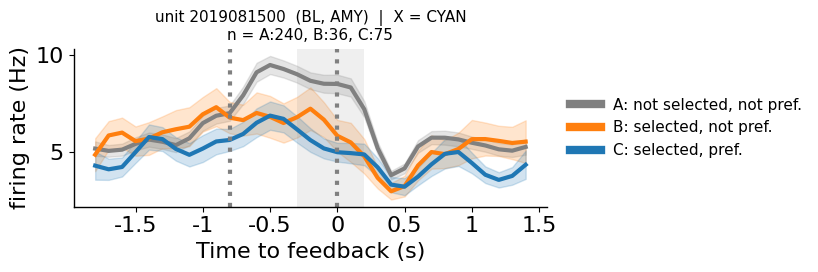

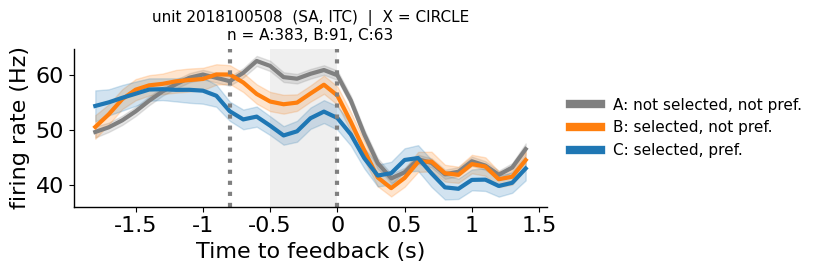

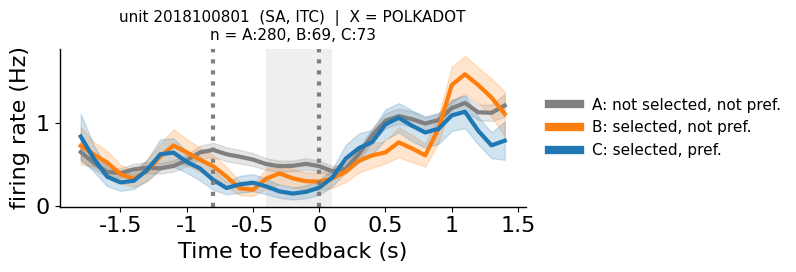

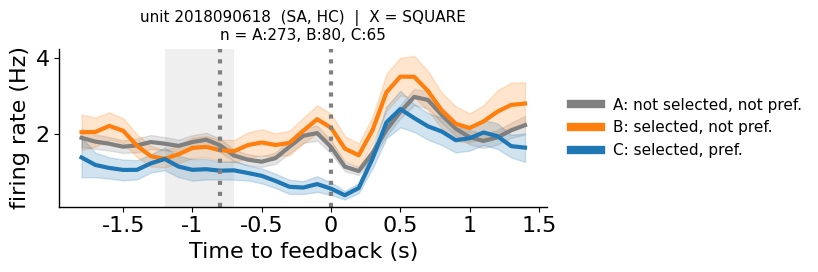

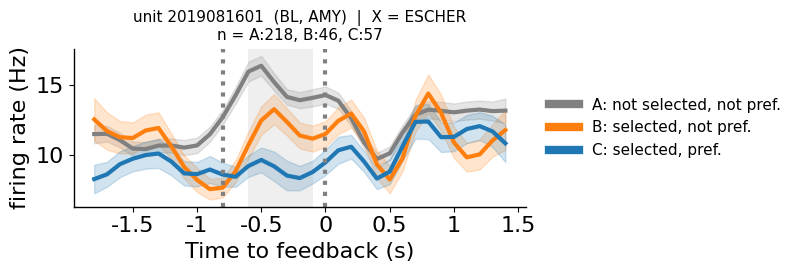

In [10]:
figs, axs = plot_examples(pick_examples(find_ordered(items, direction="A>B>C"), n_per_direction))


---

## The complement: co-selective but B extreme

The ordered units above are the *minority* of the co-selective set, and by enough that the
complement deserves a look rather than a footnote. These are the items that clear both p-value bars
and then put B outside the A-C interval: `A < B > C` or `A > B < C`, selection and preference pushing
the rate in opposite directions.

Two reasons to plot them alongside. First, calibration: they are what an ordered PSTH has to look
different from, and flipping between the two figures is the quickest check that the ordering filter
is picking up something real rather than sorting noise. Second, they are a candidate explanation of
why the population cosine is null -- a mixture of ordered and B-extreme units cancels in a signed
population average while both kinds have large magnitudes, which is branch (S) of
`stim_belief_unit_overlap.py`'s docstring rather than branch (M).

One reading worth flagging as a hypothesis and not a result: at feedback, on correct trials, group B
is *chose X while believing something else and was right anyway* -- the surprising outcome -- while
C is the expected one. A unit tracking that surprise would sit high in B and lower in both A and C,
which is precisely the B-extreme shape. That is a claim about `FeedbackOnsetLong` specifically, and
testing it needs the StimOnset item table, which has not been run.

In [11]:
def find_disordered(items, min_bins=MIN_ORDERED_BINS, alpha=ALPHA, require_pooled=True):
    """
    Co-selective items with B extreme -- the exact complement of find_ordered.

    `n_ordered <= n_bins - min_bins` is "ordered in at most as many bins as find_ordered demands are
    unordered", so the two functions are symmetric at any MIN_ORDERED_BINS and at 5 both reduce to
    "all 5 bins agree".
    """
    max_ordered = items.n_bins.iloc[0] - min_bins
    hits = items[(items.p_s <= alpha) & (items.p_p <= alpha) & (items.n_ordered <= max_ordered)]
    if require_pooled:
        hits = hits[hits.n_ordered_pool <= max_ordered]
    return hits.sort_values(["p_worse", "min_step"], ascending=[True, False]).copy()


disordered = find_disordered(items)
disordered_examples = pick_examples(disordered, n_per_direction)

print(f"{len(disordered)} co-selective items with B extreme in all {MIN_ORDERED_BINS} bins, "
      f"across {disordered.PseudoUnitID.nunique()} distinct units")
print(f"for comparison: {len(ordered)} ordered items across {ordered.PseudoUnitID.nunique()} units\n")

print("units contributing, by region:")
print(disordered.groupby("structure_level2_cleaned").PseudoUnitID.nunique()
      .rename(region_abbrev).sort_values(ascending=False).to_string(), "\n")

display(disordered_examples[cols].reset_index(drop=True))

243 co-selective items with B extreme in all 5 bins, across 101 distinct units
for comparison: 49 ordered items across 26 units

units contributing, by region:
structure_level2_cleaned
LPFC    32
ITC     24
AMY     12
DSTR    12
HC      12
ACC      9 



,PseudoUnitID,feat,WindowStartMilli,subject,structure_level2_cleaned,p_s,p_p,d_stim,d_pref,min_step,direction
0,2018092819,ESCHER,-600,SA,inferior_temporal_cortex_ITC,0.01,0.01,0.875965,-0.892459,0.875965,A<B>C
1,2018090724,ESCHER,-900,SA,amygdala_Amy,0.01,0.01,1.334389,-0.551696,0.551696,A<B>C
2,2018091813,YELLOW,100,SA,medial_pallium_MPal,0.01,0.01,0.530445,-0.466912,0.466912,A<B>C
3,2018080610,GREEN,-1800,SA,lateral_prefrontal_cortex_lat_PFC,0.01,0.01,0.457674,-0.469497,0.457674,A<B>C
4,2018080614,GREEN,700,SA,lateral_prefrontal_cortex_lat_PFC,0.01,0.01,0.457504,-0.590994,0.457504,A<B>C
5,2018091205,YELLOW,-500,SA,amygdala_Amy,0.01,0.01,0.422286,-0.499111,0.422286,A<B>C


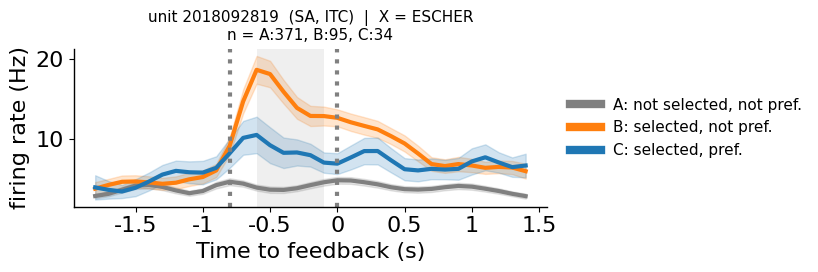

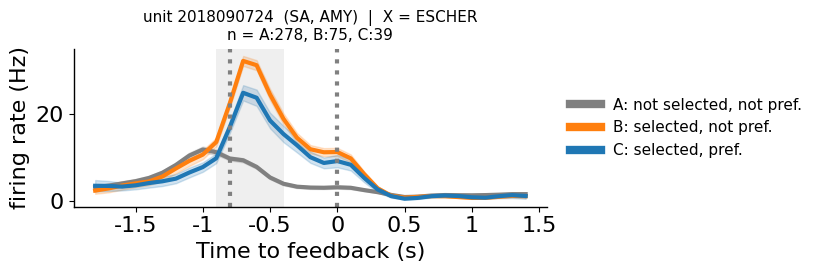

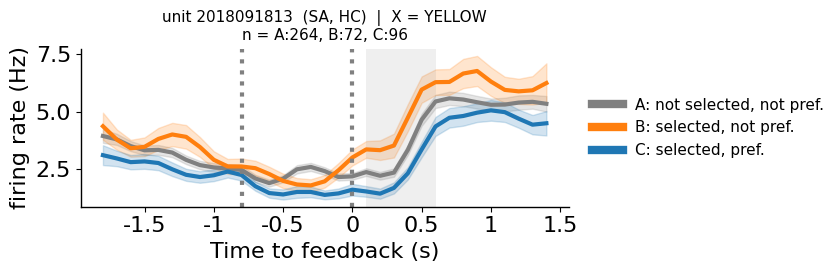

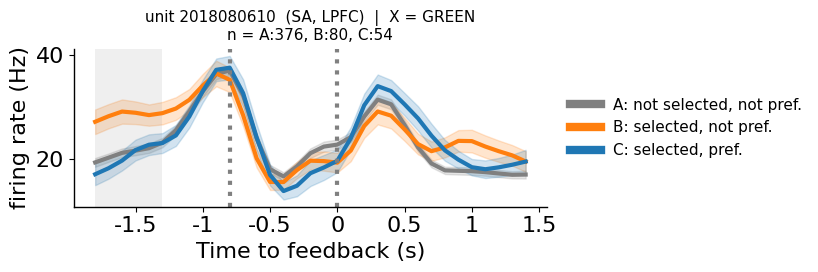

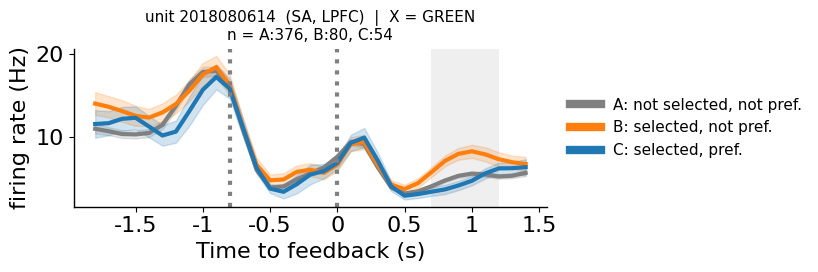

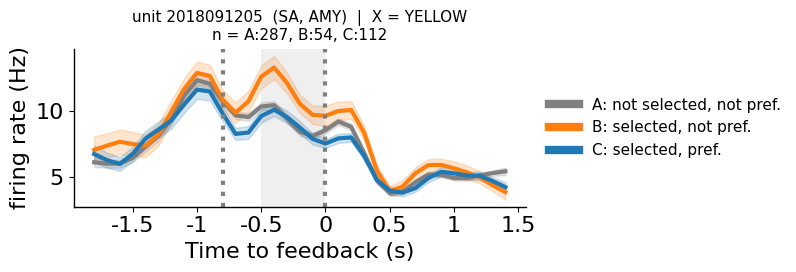

In [12]:
figs, axs = plot_examples(disordered_examples)